In [5]:
import pandas as pd

df = pd.read_csv("../data/credit_risk_dataset.csv") 
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (32581, 12)


In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")   # makes charts look clean

Matplotlib is building the font cache; this may take a moment.


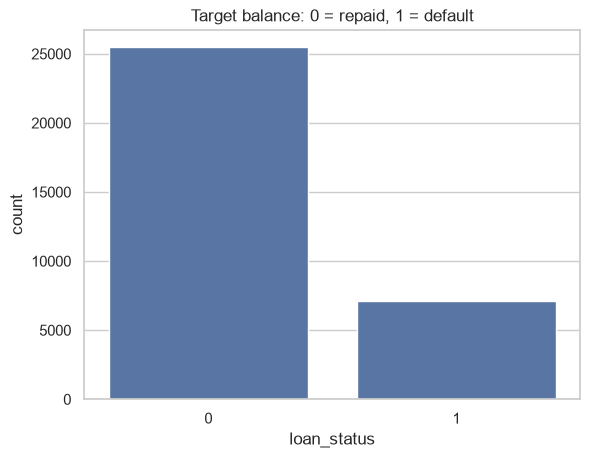

In [11]:
sns.countplot(x="loan_status", data=df)
plt.title("Target balance: 0 = repaid, 1 = default")
plt.savefig("../images/target_balance.png", dpi=120, bbox_inches="tight")
plt.show()

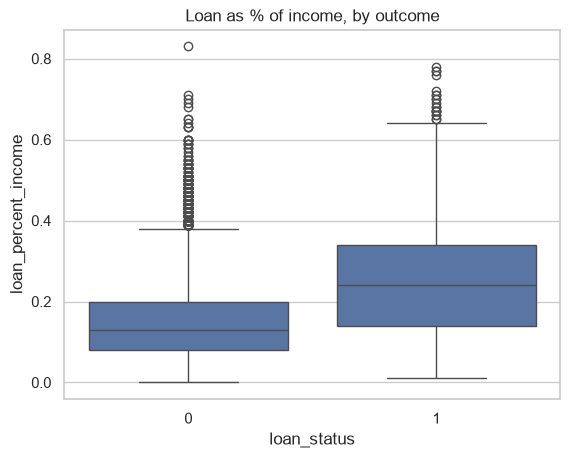

In [18]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title("Loan as % of income, by outcome")
plt.savefig("../images/pct_income_by_outcome.png", dpi=120, bbox_inches="tight")
plt.show()


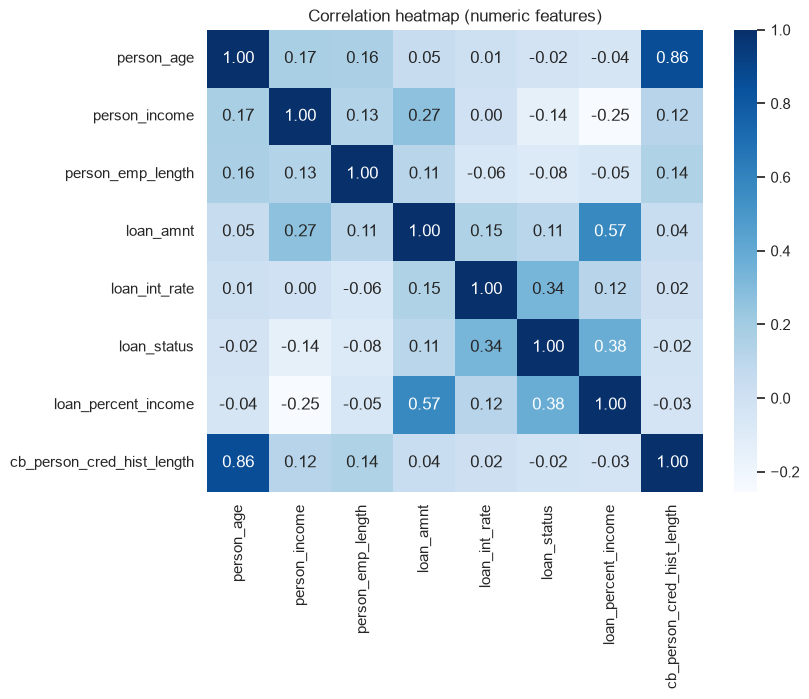

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation heatmap (numeric features)")
plt.savefig("../images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
df[["person_age", "person_emp_length"]].describe()

,person_age,person_emp_length
count,32581.000000,31686.000000
mean,27.734600,4.789686
std,6.348078,4.142630
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,144.000000,123.000000


In [20]:
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())
df["loan_int_rate"]     = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

print(df.isnull().sum())   # every column should now read 0

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [21]:
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]
print("Shape after cleaning:", df.shape)

Shape after cleaning: (32574, 12)


In [22]:
df = pd.get_dummies(df, drop_first=True)
print("New shape:", df.shape)
df.head()

New shape: (32574, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


In [23]:
X = df.drop("loan_status", axis=1)   # X = all features (everything except the answer)
y = df["loan_status"]                # y = the target (the answer: 1=default, 0=repaid)
print("Features X:", X.shape, " | Target y:", y.shape)

Features X: (32574, 22)  | Target y: (32574,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (26059, 22)  Test: (6515, 22)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/Users/apple/Documents/AI&ML - Projects/Project-1/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [26]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)            # predict on the HIDDEN test set
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.844359171143515


In [27]:
from sklearn.metrics import classification_report, roc_auc_score

proba = model.predict_proba(X_test)[:, 1]   # probability of default for each applicant
print(classification_report(y_test, preds))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      5094
           1       0.75      0.43      0.55      1421

    accuracy                           0.84      6515
   macro avg       0.80      0.70      0.73      6515
weighted avg       0.83      0.84      0.83      6515

ROC-AUC: 0.843


In [28]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "LogisticRegression": model,
    "RandomForest": RandomForestClassifier(random_state=42).fit(X_train, y_train),
    "XGBoost": XGBClassifier(eval_metric="logloss").fit(X_train, y_train),
}

for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    print(f"{name:20s} ROC-AUC: {roc_auc_score(y_test, p):.3f}")

LogisticRegression   ROC-AUC: 0.843
RandomForest         ROC-AUC: 0.928
XGBoost              ROC-AUC: 0.948


In [29]:
best = models["XGBoost"]
best_preds = best.predict(X_test)
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5094
           1       0.96      0.73      0.83      1421

    accuracy                           0.93      6515
   macro avg       0.94      0.86      0.89      6515
weighted avg       0.94      0.93      0.93      6515



In [30]:
import joblib, json
joblib.dump(best, "../model/model.pkl")
json.dump(list(X.columns), open("../model/columns.json", "w"))
print("Saved model/model.pkl and model/columns.json")

Saved model/model.pkl and model/columns.json
